In [47]:
'''
현재까지의 진행 상황:
    1. LangGraph에 대한 기초적인 이해 - Node, Edge, State등의 개념을 이해하고
    2. 이를 바탕으로 이전에 해봤던 기초적인 RAG를 LangGraph 방식으로 build하고 compile 해봤다.
    3. 더 나아가 사용자의 질문과 Retrieved doc의 연관도를 판단하고, 필요시 query를 재작성하는 conditional edge를 추가했다.


조건부 분기나 Human-in-the-loop, Self-RAG, 더 나아가 멀티 에이전트 또는 MCP까지 시도하고 싶다.

이번엔 생성된 답변을 수 차례 검증하는 Self-RAG를 구현할 것이며,
앞으로는 Human-in-the-loop를 구현해 보려고 한다.
'''

'\n현재까지의 진행 상황:\n    1. LangGraph에 대한 기초적인 이해 - Node, Edge, State등의 개념을 이해하고\n    2. 이를 바탕으로 이전에 해봤던 기초적인 RAG를 LangGraph 방식으로 build하고 compile 해봤다.\n    3. 더 나아가 사용자의 질문과 Retrieved doc의 연관도를 판단하고, 필요시 query를 재작성하는 conditional edge를 추가했다.\n\n\n조건부 분기나 Human-in-the-loop, Self-RAG, 더 나아가 멀티 에이전트 또는 MCP까지 시도하고 싶다.\n\n이번엔 생성된 답변을 수 차례 검증하는 Self-RAG를 구현할 것이며,\n앞으로는 Human-in-the-loop를 구현해 보려고 한다.\n'

In [48]:
from dotenv import load_dotenv

load_dotenv()

True

In [49]:
from langchain_upstage import UpstageEmbeddings
from langchain_chroma import Chroma


embedding = UpstageEmbeddings(model="solar-embedding-1-large")

database = Chroma(
  collection_name= 'chroma-tax',
  persist_directory= './preprocessed-upstage',
  embedding_function= embedding     
)

retriever = database.as_retriever(
    search_type= 'mmr',
    search_kwargs={
        'k': 10,
        'fetch_k': 50,
        'lamda_mult': 0.6
    }
)

In [50]:
from langchain_anthropic import ChatAnthropic
from langsmith import Client


client = Client()

llm = ChatAnthropic(
    model= 'claude-sonnet-4-20250514',
    temperature= '0.1'
)

# claude-opus-4-5-20251101
# claude-sonnet-4-5-20250929
# claude-haiku-4-5-20251001

In [51]:
from typing_extensions import List, TypedDict
from langchain_core.documents import Document


class AgentState(TypedDict):
    query: str
    context: List[Document]
    answer: str

In [52]:
from langchain_core.prompts import PromptTemplate
from langchain_core.output_parsers import StrOutputParser
from typing import Literal






def retrieve(state: AgentState):
    query  = state['query']
    docs = retriever.invoke(query)
    return {'context': docs}

relevance_check_prompt = client.pull_prompt('langchain-ai/rag-document-relevance')


def doc_relevance_check_grader(state: AgentState) -> Literal['relevant', 'irrelevant']:
    context = state['context']
    query = state['query']
    doc_relevance_chain = relevance_check_prompt | llm
    response = doc_relevance_chain.invoke({'documents': context, 'question': query})

    if response['Score'] == 1:
        return 'relevant'
    
    return 'irrelevant'







rewrite_prompt = PromptTemplate.from_template("""
당신은 한국 세법 전문가입니다.
사용자의 질문을 소득세법 문서 검색에 최적화된 형태로 다시 작성하세요.

규칙:
1. 일상 용어를 법률 용어로 변환 (예: 월급 → 근로소득)
2. 모호한 표현을 구체화
3. 검색에 필요한 핵심 키워드 포함

예시:
    소득 관련
    '월급, 급여 -> 근로소득',
    '집 팔 때 세금, 부동산 양도 -> 양도소득세',
    '이자, 배당 -> 금융소득',
    '프리랜서 수입, 외주 -> 사업소득',
    '강연료, 원고료 -> 기타소득',
    
    공제 관련
    '부양가족 공제 -> 인적공제',
    '카드 공제 -> 신용카드 소득공제',
    '의료비 공제 -> 의료비 세액공제',
    
    일반 표현
    '세금 돌려받기 -> 환급',
    '세금 신고 -> 확정신고',
    '직장인 연말 세금 -> 연말정산'

원본 질문: {query}
Retrieve 최적화된 질문:
""")

def rewrite(state: AgentState) -> AgentState:
    """
    사용자의 질문을 법률 용어에 적합하게 변경

    Args:
        state (AgentState): 사용자의 질문을 포함한 에이전트의 현재 state.

    Returns:
        AgentState: 변경된 질문을 포함하는 state를 반환
    """
    
    query = state['query']  # state에서 사용자의 질문 추출
    
    # rewrite 체인을 구성 프롬프트, LLM, 출력 파서 연결
    rewrite_chain = rewrite_prompt | llm | StrOutputParser()

    # query 변경
    response = rewrite_chain.invoke({'query': query})
    
    return {'query': response}  # 변경된 질문을 포함하는 state 반환








generate_prompt = client.pull_prompt("rlm/rag-prompt")

def generate(state: AgentState):
    context = state['context']
    query = state['query']
    rag_chain = generate_prompt | llm
    response = rag_chain.invoke({'context': context, 'question': query})
    return {'answer': response.content} 

## halluciantion check

In [53]:
from langchain_core.prompts import ChatPromptTemplate

hallucination_check_prompt = ChatPromptTemplate.from_messages([
    ("system", """당신은 AI 답변의 정확성을 평가하는 검증자입니다.

주어진 context(참고 문서)만을 기준으로, 생성된 답변이 hallucination(환각)을 포함하는지 판단하세요.

평가 기준:
1. 답변의 모든 정보가 context에 근거하는가?
2. context에 없는 내용을 지어내지 않았는가?
3. 숫자, 날짜, 법조항 등 구체적 정보가 정확한가?

점수:
- 1점: 답변이 context에 충실함 (hallucination 없음)
- 0점: 답변에 context에 없는 정보가 포함됨 (hallucination 있음)

반드시 아래 형식으로 응답하세요:
Score: [0 또는 1]
Explanation: [판단 이유]
"""),
    ("human", """
Context:
{context}

생성된 답변:
{answer}

위 답변이 context에 충실한지 평가해주세요.
""")
])

hallucination_llm = ChatAnthropic(model='claude-haiku-4-5-20251001', temperature=0)

def hallucination_check(state: AgentState) -> Literal['hallucinated', 'not hallucinated']:
    answer = state['answer']
    context = state['context']
    context = [doc.page_content for doc in context]
    
    hallucination_chain = hallucination_check_prompt | hallucination_llm | StrOutputParser()
    response = hallucination_chain.invoke({'answer': answer, 'context': context})

    if "Score: 1" in response:
        return 'not hallucinated'
    
    return 'hallucinated'

In [54]:
# query = '원천징수 대상 기타소득에는 어떤 것이 있나요?'
# context = retriever.invoke(query)




# generate_state = {'query': query, 'context': context}
# generated = generate(generate_state)





# halu_state = {'query': query, 'context': context, 'answer': generated['answer']}                          
# hallu_hallu = hallucination_check(halu_state)

In [55]:
# generated

## 생성된 답변의 Helpfulness

In [56]:
def helpfulness_node(state: AgentState):
    return state


helpfulness_prompt = client.pull_prompt("langchain-ai/rag-answer-helpfulness")

def check_helpfulness_grader(state: AgentState) -> Literal['helpful', 'not helpful']:
    query = state['query']
    answer = state['answer']
    helpfulness_chain = helpfulness_prompt | llm
    response = helpfulness_chain.invoke({'question': query, 'student_answer': answer})

    if response['Score'] == 1:
        return 'helpful'
    
    return 'not helpful'

In [57]:
# halu_state

In [58]:
# check_helpfulness(halu_state)

## Chain 조립 시작

In [59]:
from langgraph.graph import StateGraph
from langgraph.graph import START, END


graph_builder = StateGraph(AgentState)

graph_builder.add_node('retrieve', retrieve)
graph_builder.add_node('generate', generate)
graph_builder.add_node('rewrite', rewrite)
graph_builder.add_node('check_helpfulness', helpfulness_node)



graph_builder.add_edge(START, 'retrieve')

graph_builder.add_conditional_edges(
    'retrieve',
    doc_relevance_check_grader,
    {
        'relevant': 'generate',
        'irrelevant': END
    }
)

graph_builder.add_conditional_edges(
    'generate',
    hallucination_check,
    {
        'not hallucinated': 'check_helpfulness',
        'hallucinated': 'generate'
    }
)

graph_builder.add_conditional_edges(
    'check_helpfulness',
    check_helpfulness_grader,
    {
        'helpful': END,
        'not helpful': 'rewrite'
    }
)

graph_builder.add_edge('rewrite', 'retrieve')


graph = graph_builder.compile()

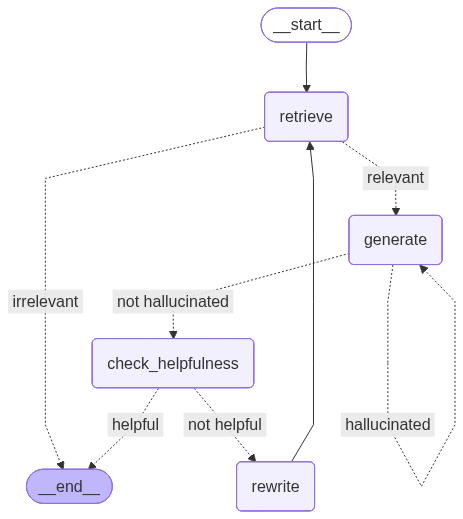

In [60]:
from IPython.display import display, Image

display(Image(graph.get_graph().draw_mermaid_png()))

In [61]:
query='원천징수 대상 사업소득에 대해서 알려줘'
initial_state = {'query': query}
response = graph.invoke(initial_state)

In [62]:
response['answer']

'원천징수 대상 사업소득은 대통령령으로 정하는 사업소득을 의미합니다. 원천징수의무자가 이러한 사업소득을 지급할 때에는 지급금액에 원천징수세율을 적용하여 계산한 소득세를 원천징수하고, 원천징수영수증을 사업소득자에게 발급해야 합니다. 구체적인 사업의 범위나 세부 기준은 대통령령에서 별도로 정하고 있습니다.'

In [63]:
'''
hallucination이 있을 때 무작정 다시 generate 하는 것보다,
hallucination_check의 사유를 prompt에 반영하는 regenerate node를 만들어 보고 싶다.
'''

'\nhallucination이 있을 때 무작정 다시 generate 하는 것보다,\nhallucination_check의 사유를 prompt에 반영하는 regenerate node를 만들어 보고 싶다.\n'